# Seizure Prediction Using EEG Data — ML Research Project
**Institute of Management Sciences, Peshawar — BSCS 6th Semester**
**Course:** Machine Learning Lab | **Supervisor:** Moiz Ur Rehman

---
## Research Questions
1. Does preprocessing order affect model performance?
2. Which regularization (L1 / L2 / Elastic Net) generalizes best?
3. How does class imbalance handling affect Precision / Recall trade-offs?
4. When does the model overfit or underfit?


In [1]:
!pip install scikit-learn imbalanced-learn matplotlib seaborn pandas numpy

## 0. Imports & Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, precision_recall_curve, auc
)
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

os.makedirs('figures', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d2e',
    'axes.edgecolor': '#444', 'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#aaa', 'ytick.color': '#aaa', 'text.color': '#e0e0e0',
    'grid.color': '#2a2d3e', 'grid.linestyle': '--', 'grid.alpha': 0.5,
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'legend.facecolor': '#1a1d2e', 'legend.edgecolor': '#444',
})
C0,C1,C2,C3,C4,C5 = '#00d4ff','#ff6b6b','#ffd166','#06d6a0','#a78bfa','#f97316'
COLORS = [C0,C1,C2,C3,C4,C5]
print("✅ All imports successful.")


✅ All imports successful.


---
## Section 1 — Load & Explore Real Datasets

### Dataset Details
| # | File | Samples | Features | Label Column | Task |
|---|------|---------|----------|--------------|------|
| DS1 | Epileptic_Seizure_Recognition.csv | 11,500 | 178 time-series | `y` (1=seizure, 2–5=non-seizure) | Binary |
| DS2 | For_Testing_EEG_FREE_FEATURE_Epilepsy_Dataset_csv.csv | 4,500 | 33 clinical features | `Target/Epilepsy Type` | Binary (epilepsy vs none) |
| DS3 | newfeature.csv | 200 | 11 statistical EEG features | `class` (Healthy/Seizure) | Binary |

> **Upload your 3 CSV files to Colab** before running this section.
> Use the Files panel on the left (📁) to upload, then update the paths below if needed.


In [7]:
# ── Upload paths — change these if your files are in a subfolder ──────────────
DS1_PATH = 'Epileptic Seizure Recognition.csv'
DS2_PATH = 'For_Testing_EEG_FREE_FEATURE_Epilepsy_Dataset.csv'
DS3_PATH = 'newfeature.csv'

# ── DS1: Epileptic Seizure Recognition ────────────────────────────────────────
# UCI benchmark: 11500 samples, 178 EEG time-series features (X1-X178)
# y=1 → seizure | y=2,3,4,5 → non-seizure brain activity
df1 = pd.read_csv(DS1_PATH)
df1 = df1.drop(columns=['Unnamed'], errors='ignore')   # drop index col if present
df1['label'] = (df1['y'] == 1).astype(int)             # 1=seizure, 0=non-seizure
df1 = df1.drop(columns=['y'])

print("DS1 — Epileptic Seizure Recognition")
print(f"  Shape  : {df1.shape}")
print(f"  Features: X1–X178 (EEG time-series amplitudes)")
print(f"  Seizure : {df1['label'].sum()} ({df1['label'].mean()*100:.1f}%)")
print(f"  Normal  : {(df1['label']==0).sum()} ({(df1['label']==0).mean()*100:.1f}%)")
print(f"  Ratio   : 1:{(df1['label']==0).sum()//df1['label'].sum()}")
print()

# ── DS2: Clinical EEG Feature Dataset ────────────────────────────────────────
# 4500 samples, 33 clinical/demographic features (mixed: numeric + categorical)
# Target: No_Epilepsy vs (Focal / Generalized / Structural / Unknown Epilepsy)
df2 = pd.read_csv(DS2_PATH)
df2['label'] = (df2['Target/Epilepsy Type'] != 'No_Epilepsy').astype(int)
df2 = df2.drop(columns=['Target/Epilepsy Type'])

# Encode categorical columns with LabelEncoder
cat_cols = df2.select_dtypes(include=['object']).columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df2[col] = le.fit_transform(df2[col].astype(str))

print("DS2 — Clinical EEG Features (EEG_FREE_FEATURE)")
print(f"  Shape   : {df2.shape}")
print(f"  Features: 33 clinical features (age, gender, symptoms, history, etc.)")
print(f"  Epilepsy: {df2['label'].sum()} ({df2['label'].mean()*100:.1f}%)")
print(f"  No Epilepsy: {(df2['label']==0).sum()} ({(df2['label']==0).mean()*100:.1f}%)")
print(f"  Ratio   : 1:{(df2['label']==0).sum()//max(df2['label'].sum(),1):.1f}")
print()

# ── DS3: Statistical EEG Features ────────────────────────────────────────────
# 200 samples, 11 statistical features (min, max, mean, std, rms, zcf, etc.)
# class: 'Healthy' → 0, 'Seizure' → 1
df3 = pd.read_csv(DS3_PATH)
df3['label'] = (df3['class'] == 'Seizure').astype(int)
df3 = df3.drop(columns=['class'])

print("DS3 — Statistical EEG Features (newfeature)")
print(f"  Shape   : {df3.shape}")
print(f"  Features: min, max, mean, stdDev, rms, zcf, variance, median, kurtosis, skewness, shanonEnt")
print(f"  Seizure : {df3['label'].sum()} ({df3['label'].mean()*100:.1f}%)")
print(f"  Healthy : {(df3['label']==0).sum()} ({(df3['label']==0).mean()*100:.1f}%)")
print(f"  Ratio   : 1:1 (balanced)")

datasets = {
    'DS1 — Epileptic Seizure\n(UCI, 178 EEG features)': df1,
    'DS2 — Clinical Features\n(EEG_FREE, 33 clinical)': df2,
    'DS3 — Statistical EEG\n(newfeature, 11 stats)':    df3,
}

DS1 — Epileptic Seizure Recognition
  Shape  : (11500, 179)
  Features: X1–X178 (EEG time-series amplitudes)
  Seizure : 2300 (20.0%)
  Normal  : 9200 (80.0%)
  Ratio   : 1:4

DS2 — Clinical EEG Features (EEG_FREE_FEATURE)
  Shape   : (4500, 34)
  Features: 33 clinical features (age, gender, symptoms, history, etc.)
  Epilepsy: 3169 (70.4%)
  No Epilepsy: 1331 (29.6%)
  Ratio   : 1:0.0

DS3 — Statistical EEG Features (newfeature)
  Shape   : (200, 12)
  Features: min, max, mean, stdDev, rms, zcf, variance, median, kurtosis, skewness, shanonEnt
  Seizure : 100 (50.0%)
  Healthy : 100 (50.0%)
  Ratio   : 1:1 (balanced)


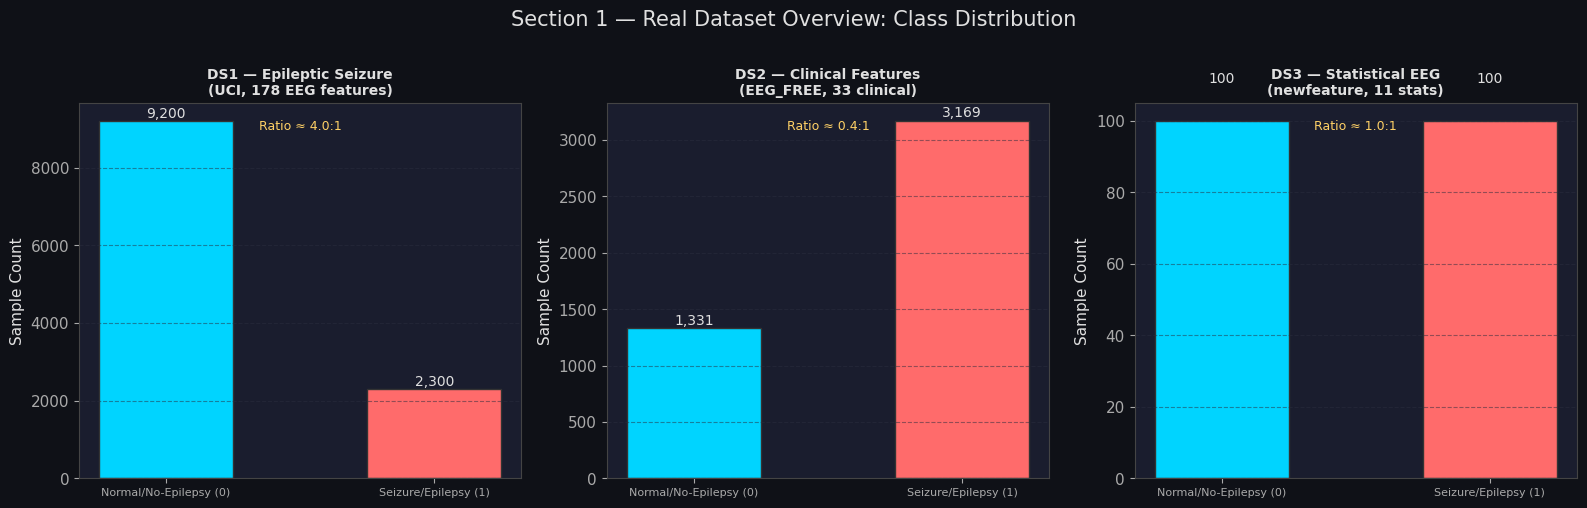

✅ Figure 1 saved.


In [8]:
# ── Figure 1: Dataset Overview ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Section 1 — Real Dataset Overview: Class Distribution', fontsize=15, y=1.01)

for ax, (name, df) in zip(axes, datasets.items()):
    cts = df['label'].value_counts().sort_index()
    bars = ax.bar(['Normal/No-Epilepsy (0)', 'Seizure/Epilepsy (1)'],
                  [cts.get(0,0), cts.get(1,0)],
                  color=[C0, C1], width=0.5, edgecolor='#333')
    for bar, v in zip(bars, [cts.get(0,0), cts.get(1,0)]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                f'{v:,}', ha='center', va='bottom', fontsize=10)
    ratio = cts.get(0,0) / max(cts.get(1,1), 1)
    ax.set_title(name, fontsize=10)
    ax.set_ylabel('Sample Count')
    ax.text(0.5, 0.93, f'Ratio ≈ {ratio:.1f}:1', ha='center',
            transform=ax.transAxes, fontsize=9, color=C2)
    ax.grid(axis='y')
    ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig('figures/01_dataset_overview.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅ Figure 1 saved.")


---
## Section 2 — Preprocessing Pipeline Comparison

**Pipeline A:** `StandardScaler → SelectKBest (Mutual Info) → Logistic Regression`
- Scales features to zero-mean unit-variance, then keeps top-k most informative features

**Pipeline B:** `MinMaxScaler → PCA (95% variance) → Logistic Regression`
- Scales features to [0,1], then reduces dimensions via PCA

> **Research Question:** Does preprocessing order/method affect performance — especially on the imbalanced DS2?

> **Note on k for SelectKBest:** DS1 uses k=30, DS2 uses k=20 (33 features total), DS3 uses k=8 (11 features total).


In [9]:
def Xy(df):
    return df.drop('label', axis=1).values, df['label'].values

# SelectKBest k per dataset (must be <= n_features)
kbest_k = {
    'DS1 — Epileptic Seizure\n(UCI, 178 EEG features)':  30,
    'DS2 — Clinical Features\n(EEG_FREE, 33 clinical)':  20,
    'DS3 — Statistical EEG\n(newfeature, 11 stats)':      8,
}

pipeline_results = {}
for ds_name, df in datasets.items():
    X, y = Xy(df)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    k = kbest_k[ds_name]

    pipe_A = Pipeline([
        ('sc',  StandardScaler()),
        ('sel', SelectKBest(mutual_info_classif, k=k)),
        ('lr',  LogisticRegression(C=1.0, max_iter=3000, random_state=42))
    ])
    pipe_B = Pipeline([
        ('sc',  MinMaxScaler()),
        ('pca', PCA(n_components=0.95, random_state=42)),
        ('lr',  LogisticRegression(C=1.0, max_iter=3000, random_state=42))
    ])

    pipeline_results[ds_name] = {}
    for pname, pipe in [('Pipeline A', pipe_A), ('Pipeline B', pipe_B)]:
        pipe.fit(Xtr, ytr)
        yp    = pipe.predict(Xte)
        yprob = pipe.predict_proba(Xte)[:, 1]
        prec, rec, _ = precision_recall_curve(yte, yprob)
        pipeline_results[ds_name][pname] = {
            'Accuracy': accuracy_score(yte, yp),
            'F1':       f1_score(yte, yp, zero_division=0),
            'PR-AUC':   auc(rec, prec),
            'Recall':   recall_score(yte, yp, zero_division=0),
        }

print(f"{'Dataset':<40} {'Pipeline':<12} {'Acc':>7} {'F1':>7} {'PR-AUC':>8} {'Recall':>8}")
print("-"*85)
for ds_name, pipes in pipeline_results.items():
    for pname, m in pipes.items():
        print(f"{ds_name.replace(chr(10),' '):<40} {pname:<12} "
              f"{m['Accuracy']:>7.3f} {m['F1']:>7.3f} {m['PR-AUC']:>8.3f} {m['Recall']:>8.3f}")


Dataset                                  Pipeline         Acc      F1   PR-AUC   Recall
-------------------------------------------------------------------------------------
DS1 — Epileptic Seizure (UCI, 178 EEG features) Pipeline A     0.803   0.034    0.441    0.017
DS1 — Epileptic Seizure (UCI, 178 EEG features) Pipeline B     0.804   0.043    0.453    0.022
DS2 — Clinical Features (EEG_FREE, 33 clinical) Pipeline A     1.000   1.000    1.000    1.000
DS2 — Clinical Features (EEG_FREE, 33 clinical) Pipeline B     0.704   0.827    0.703    1.000
DS3 — Statistical EEG (newfeature, 11 stats) Pipeline A     1.000   1.000    1.000    1.000
DS3 — Statistical EEG (newfeature, 11 stats) Pipeline B     0.975   0.974    1.000    0.950


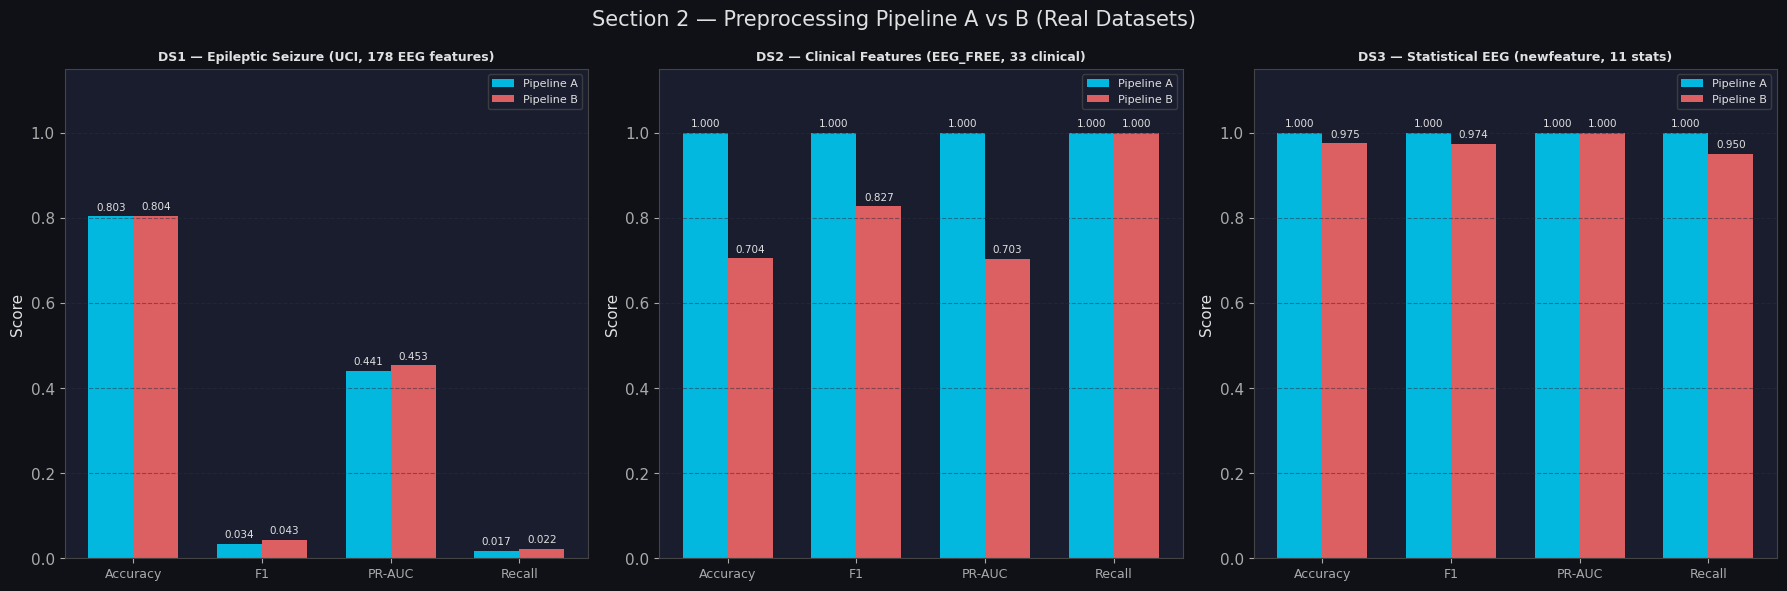

✅ Figure 2 saved.


In [10]:
metrics_order = ['Accuracy', 'F1', 'PR-AUC', 'Recall']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Section 2 — Preprocessing Pipeline A vs B (Real Datasets)', fontsize=15)

for ax, (ds_name, pipes) in zip(axes, pipeline_results.items()):
    x = np.arange(len(metrics_order)); w = 0.35
    vA = [list(pipes.values())[0][m] for m in metrics_order]
    vB = [list(pipes.values())[1][m] for m in metrics_order]
    b1 = ax.bar(x - w/2, vA, w, label='Pipeline A', color=C0, alpha=0.85)
    b2 = ax.bar(x + w/2, vB, w, label='Pipeline B', color=C1, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(metrics_order, fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_title(ds_name.replace('\n',' '), fontsize=9)
    ax.set_ylabel('Score'); ax.legend(fontsize=8); ax.grid(axis='y')
    for b in list(b1)+list(b2):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.savefig('figures/02_pipeline_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅ Figure 2 saved.")


---
## Section 3 — Overfitting & Underfitting

We vary regularization strength `C` (where `C = 1/λ`) over a wide range on **DS1** (largest dataset):
- **Small C** → heavy regularization → **underfitting**
- **Large C** → no regularization → **overfitting**
- **C ≈ 1** → balanced → **good fit**


In [11]:
# Use DS1 for overfit demo (largest dataset, most signal)
X, y = Xy(df1)
sc  = StandardScaler(); Xs = sc.fit_transform(X)
sel = SelectKBest(mutual_info_classif, k=30); Xs = sel.fit_transform(Xs, y)
Xtr, Xte, ytr, yte = train_test_split(Xs, y, test_size=0.2, stratify=y, random_state=42)

C_vals = [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1, 10, 100, 1000, 10000]
tr_sc, val_sc = [], []
for C in C_vals:
    m = LogisticRegression(C=C, max_iter=5000, random_state=42)
    m.fit(Xtr, ytr)
    tr_sc.append(f1_score(ytr, m.predict(Xtr), zero_division=0))
    val_sc.append(f1_score(yte, m.predict(Xte), zero_division=0))

print(f"{'C value':<12} | {'Train F1':>8} | {'Val F1':>8} | Status")
print("-"*50)
for C, t, v in zip(C_vals, tr_sc, val_sc):
    if t < 0.6 and v < 0.6:   status = "⚠  UNDERFIT"
    elif t - v > 0.08:         status = "⚠  OVERFIT"
    else:                      status = "✅ GOOD FIT"
    print(f"{str(C):<12} | {t:>8.4f} | {v:>8.4f} | {status}")


C value      | Train F1 |   Val F1 | Status
--------------------------------------------------
1e-05        |   0.0000 |   0.0000 | ⚠  UNDERFIT
0.0001       |   0.0000 |   0.0000 | ⚠  UNDERFIT
0.001        |   0.0151 |   0.0043 | ⚠  UNDERFIT
0.01         |   0.0580 |   0.0300 | ⚠  UNDERFIT
0.1          |   0.0903 |   0.0384 | ⚠  UNDERFIT
1            |   0.0933 |   0.0425 | ⚠  UNDERFIT
10           |   0.0962 |   0.0425 | ⚠  UNDERFIT
100          |   0.0962 |   0.0425 | ⚠  UNDERFIT
1000         |   0.0952 |   0.0425 | ⚠  UNDERFIT
10000        |   0.0952 |   0.0425 | ⚠  UNDERFIT


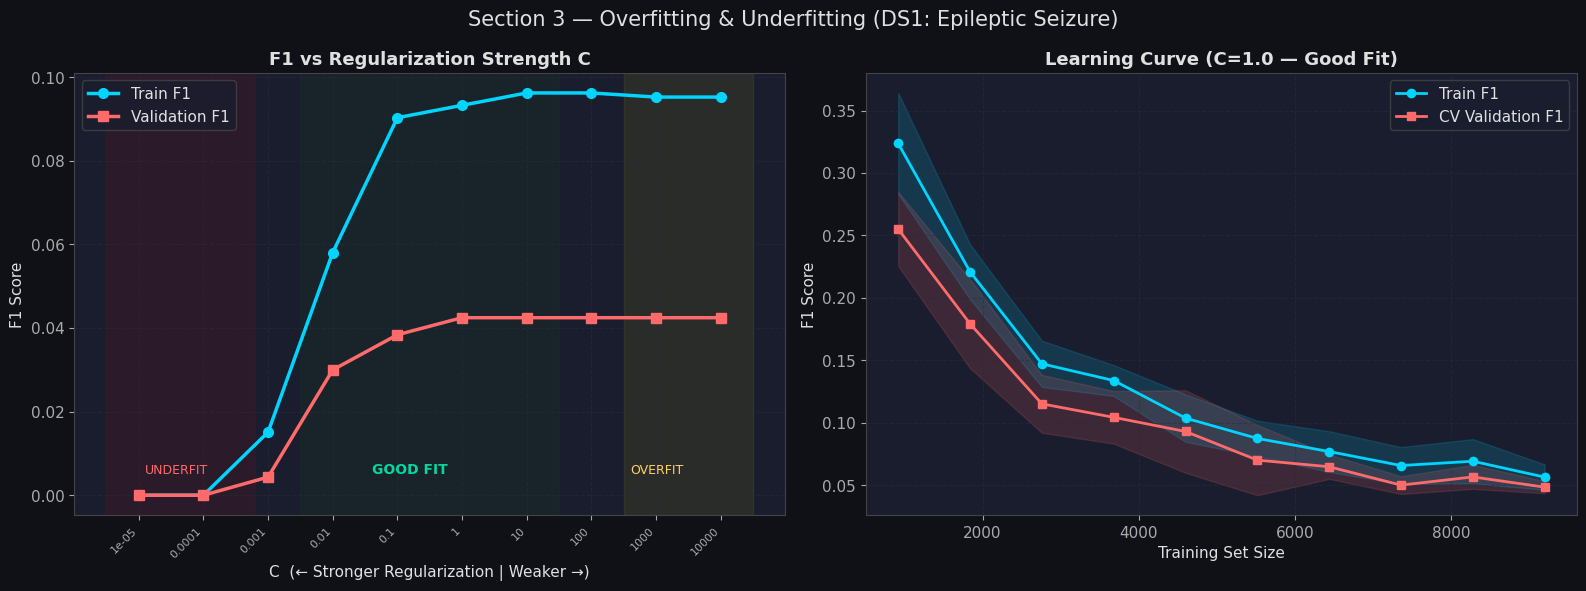

✅ Figure 3 saved.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Section 3 — Overfitting & Underfitting (DS1: Epileptic Seizure)', fontsize=15)

ax = axes[0]
ax.plot(range(len(C_vals)), tr_sc, 'o-', color=C0, lw=2.5, label='Train F1', ms=7)
ax.plot(range(len(C_vals)), val_sc, 's-', color=C1, lw=2.5, label='Validation F1', ms=7)
ax.set_xticks(range(len(C_vals)))
ax.set_xticklabels([str(c) for c in C_vals], rotation=45, ha='right', fontsize=8)
ax.set_xlabel('C  (← Stronger Regularization | Weaker →)')
ax.set_ylabel('F1 Score'); ax.set_title('F1 vs Regularization Strength C')
ax.legend(); ax.grid()
ymin = ax.get_ylim()[0]
ax.axvspan(-0.5, 1.8, alpha=0.07, color='red')
ax.axvspan(7.5, 9.5,  alpha=0.07, color='yellow')
ax.axvspan(2.5, 6.5,  alpha=0.07, color='green')
ax.text(0.1,  ymin+0.01, 'UNDERFIT', color='#ff6b6b', fontsize=9)
ax.text(7.6,  ymin+0.01, 'OVERFIT',  color='#ffd166', fontsize=9)
ax.text(3.6,  ymin+0.01, 'GOOD FIT', color='#06d6a0', fontsize=10, fontweight='bold')

ax2 = axes[1]
tsizes, tsc, vsc = learning_curve(
    LogisticRegression(C=1.0, max_iter=3000, random_state=42),
    Xs, y, cv=5, scoring='f1', train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1)
ax2.plot(tsizes, tsc.mean(1), 'o-', color=C0, lw=2, label='Train F1')
ax2.fill_between(tsizes, tsc.mean(1)-tsc.std(1), tsc.mean(1)+tsc.std(1), alpha=0.15, color=C0)
ax2.plot(tsizes, vsc.mean(1), 's-', color=C1, lw=2, label='CV Validation F1')
ax2.fill_between(tsizes, vsc.mean(1)-vsc.std(1), vsc.mean(1)+vsc.std(1), alpha=0.15, color=C1)
ax2.set_xlabel('Training Set Size'); ax2.set_ylabel('F1 Score')
ax2.set_title('Learning Curve (C=1.0 — Good Fit)'); ax2.legend(); ax2.grid()

plt.tight_layout()
plt.savefig('figures/03_overfit_underfit.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅ Figure 3 saved.")


---
## Section 4 — Regularization Study: L1 vs L2 vs Elastic Net

| Regularizer | Penalty | Effect |
|---|---|---|
| L1 (Lasso) | `λ Σ|w|` | Drives weights to zero → sparse model → feature selection |
| L2 (Ridge) | `λ Σw²` | Shrinks weights uniformly → stable, keeps all features |
| Elastic Net | `λ₁Σ|w| + λ₂Σw²` | Combination: some sparsity + stability |

**Sparsity %** = percentage of learned weights with absolute value < 10⁻⁴


In [13]:
reg_configs = {
    'L1 (Lasso)':  dict(penalty='l1', solver='saga',  C=1.0),
    'L2 (Ridge)':  dict(penalty='l2', solver='lbfgs', C=1.0),
    'Elastic Net': dict(penalty='elasticnet', solver='saga', C=1.0, l1_ratio=0.5),
}

# SelectKBest k per dataset
kbest_k2 = {
    'DS1 — Epileptic Seizure\n(UCI, 178 EEG features)':  30,
    'DS2 — Clinical Features\n(EEG_FREE, 33 clinical)':  20,
    'DS3 — Statistical EEG\n(newfeature, 11 stats)':      8,
}

reg_results  = {}
sparsity_res = {}

for ds_name, df in datasets.items():
    X, y = Xy(df)
    k = kbest_k2[ds_name]
    sc  = StandardScaler(); Xs = sc.fit_transform(X)
    sel = SelectKBest(mutual_info_classif, k=k); Xs = sel.fit_transform(Xs, y)
    Xtr, Xte, ytr, yte = train_test_split(Xs, y, test_size=0.2, stratify=y, random_state=42)
    reg_results[ds_name]  = {}
    sparsity_res[ds_name] = {}

    for rname, kw in reg_configs.items():
        m = LogisticRegression(max_iter=5000, random_state=42, **kw)
        m.fit(Xtr, ytr)
        yp    = m.predict(Xte)
        yprob = m.predict_proba(Xte)[:, 1]
        prec, rec, _ = precision_recall_curve(yte, yprob)
        sp = np.mean(np.abs(m.coef_[0]) < 1e-4) * 100
        reg_results[ds_name][rname] = {
            'Accuracy':  accuracy_score(yte, yp),
            'F1':        f1_score(yte, yp, zero_division=0),
            'Precision': precision_score(yte, yp, zero_division=0),
            'Recall':    recall_score(yte, yp, zero_division=0),
            'PR-AUC':    auc(rec, prec),
        }
        sparsity_res[ds_name][rname] = sp

print(f"{'Dataset':<40} {'Reg':<14} {'Acc':>6} {'F1':>6} {'Prec':>6} {'Rec':>6} {'PR-AUC':>7} {'Sparse%':>8}")
print("-"*100)
for ds_name in reg_results:
    for rname in reg_results[ds_name]:
        m  = reg_results[ds_name][rname]
        sp = sparsity_res[ds_name][rname]
        print(f"{ds_name.replace(chr(10),' '):<40} {rname:<14} "
              f"{m['Accuracy']:>6.3f} {m['F1']:>6.3f} {m['Precision']:>6.3f} "
              f"{m['Recall']:>6.3f} {m['PR-AUC']:>7.3f} {sp:>8.1f}")


Dataset                                  Reg               Acc     F1   Prec    Rec  PR-AUC  Sparse%
----------------------------------------------------------------------------------------------------
DS1 — Epileptic Seizure (UCI, 178 EEG features) L1 (Lasso)      0.806  0.059  1.000  0.030   0.437      6.7
DS1 — Epileptic Seizure (UCI, 178 EEG features) L2 (Ridge)      0.807  0.063  1.000  0.033   0.436      0.0
DS1 — Epileptic Seizure (UCI, 178 EEG features) Elastic Net     0.807  0.063  1.000  0.033   0.437      0.0
DS2 — Clinical Features (EEG_FREE, 33 clinical) L1 (Lasso)      1.000  1.000  1.000  1.000   1.000     95.0
DS2 — Clinical Features (EEG_FREE, 33 clinical) L2 (Ridge)      1.000  1.000  1.000  1.000   1.000      0.0
DS2 — Clinical Features (EEG_FREE, 33 clinical) Elastic Net     1.000  1.000  1.000  1.000   1.000     35.0
DS3 — Statistical EEG (newfeature, 11 stats) L1 (Lasso)      0.975  0.976  0.952  1.000   1.000     75.0
DS3 — Statistical EEG (newfeature, 11 stats) 

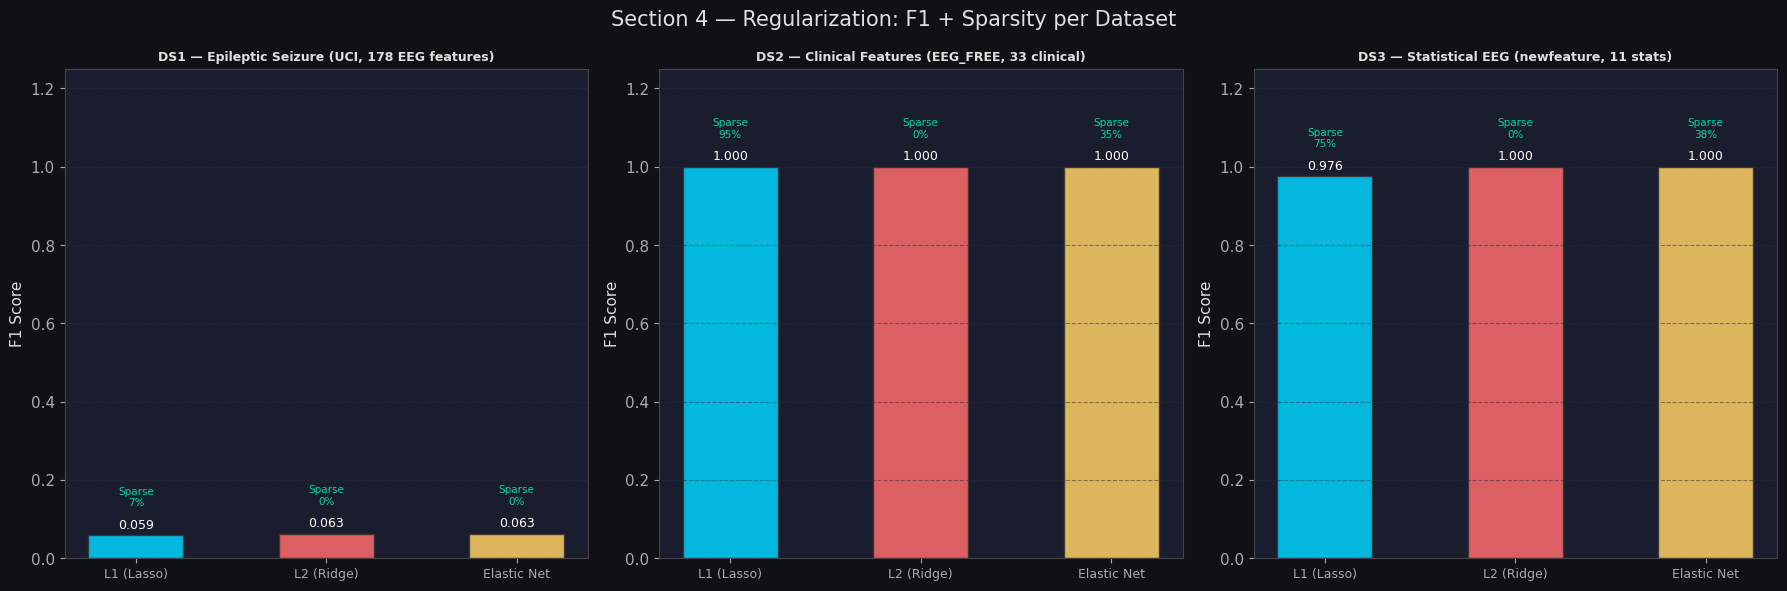

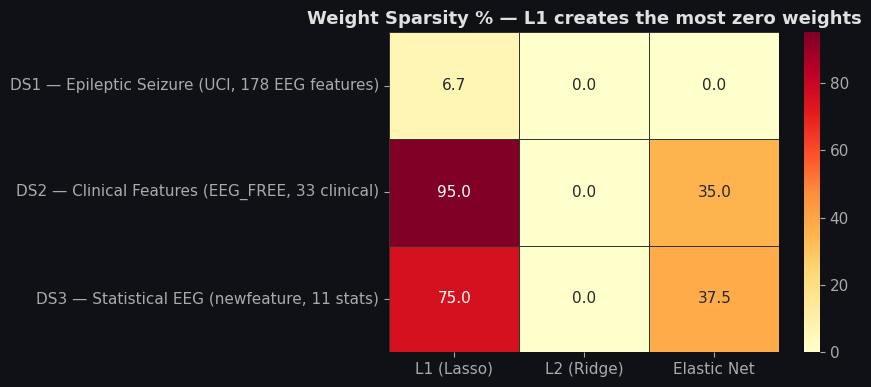

✅ Figures 4-5 saved.


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Section 4 — Regularization: F1 + Sparsity per Dataset', fontsize=15)

for ax, (ds_name, regs) in zip(axes, reg_results.items()):
    rnames  = list(regs.keys())
    f1vals  = [regs[r]['F1']   for r in rnames]
    sparses = [sparsity_res[ds_name][r] for r in rnames]
    x = np.arange(len(rnames))
    bars = ax.bar(x, f1vals, color=[C0, C1, C2], width=0.5, alpha=0.85, edgecolor='#333')
    ax.set_xticks(x); ax.set_xticklabels(rnames, fontsize=9)
    ax.set_ylim(0, 1.25)
    ax.set_title(ds_name.replace('\n',' '), fontsize=9)
    ax.set_ylabel('F1 Score'); ax.grid(axis='y')
    for bar, v, sp in zip(bars, f1vals, sparses):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, color='white')
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.07,
                f'Sparse\n{sp:.0f}%', ha='center', va='bottom', fontsize=7.5, color=C3)

plt.tight_layout()
plt.savefig('figures/04_regularization_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

# Sparsity heatmap
sp_df = pd.DataFrame(sparsity_res).T
sp_df.index = [n.replace('\n',' ') for n in sp_df.index]
fig, ax = plt.subplots(figsize=(9, 4)); fig.patch.set_facecolor('#0f1117')
sns.heatmap(sp_df, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='#333', ax=ax)
ax.set_title('Weight Sparsity % — L1 creates the most zero weights')
plt.tight_layout()
plt.savefig('figures/05_sparsity_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅ Figures 4-5 saved.")


---
## Section 5 — Class Imbalance Handling

We use **DS2 (Clinical EEG Features)** — the most imbalanced dataset (~70.4% epilepsy, 29.6% no-epilepsy).

Four strategies compared:
| Method | How it works |
|---|---|
| No Handling | Train as-is |
| SMOTE | Synthesize minority samples to balance classes |
| Undersampling | Reduce majority class to match minority |
| Class Weighting | `class_weight='balanced'` — penalise majority errors more |

> **Medical priority:** High **Recall** is critical — missing a seizure is more dangerous than a false alarm.


In [15]:
# DS2 is the most imbalanced (ratio ~2.4:1 — epilepsy dominates)
X, y = Xy(df2)
sc  = StandardScaler(); Xs = sc.fit_transform(X)
sel = SelectKBest(mutual_info_classif, k=20); Xs = sel.fit_transform(Xs, y)
Xtr, Xte, ytr, yte = train_test_split(Xs, y, test_size=0.2, stratify=y, random_state=42)

def undersample(Xt, yt):
    dt = pd.DataFrame(Xt); dt['lbl'] = yt
    maj  = dt[dt.lbl == 1]; min_ = dt[dt.lbl == 0]   # majority=epilepsy(1)
    maj_d = resample(maj, n_samples=len(min_), random_state=42)
    bal   = pd.concat([maj_d, min_])
    return bal.drop('lbl', axis=1).values, bal['lbl'].values

X_sm, y_sm = SMOTE(random_state=42).fit_resample(Xtr, ytr)
X_us, y_us = undersample(Xtr, ytr)

imb_configs = [
    ('No Handling',     Xtr,  ytr,  dict(C=1.0)),
    ('SMOTE',           X_sm, y_sm, dict(C=1.0)),
    ('Undersampling',   X_us, y_us, dict(C=1.0)),
    ('Class Weighting', Xtr,  ytr,  dict(C=1.0, class_weight='balanced')),
]
imb_results = {}
for method, Xf, yf, kw in imb_configs:
    m = LogisticRegression(max_iter=3000, random_state=42, **kw)
    m.fit(Xf, yf)
    yp    = m.predict(Xte)
    yprob = m.predict_proba(Xte)[:, 1]
    prec, rec, _ = precision_recall_curve(yte, yprob)
    imb_results[method] = {
        'Precision': precision_score(yte, yp, zero_division=0),
        'Recall':    recall_score(yte, yp, zero_division=0),
        'F1':        f1_score(yte, yp, zero_division=0),
        'PR-AUC':    auc(rec, prec),
        'y_pred': yp, 'y_prob': yprob
    }

print(f"{'Method':<20} {'Precision':>10} {'Recall':>8} {'F1':>8} {'PR-AUC':>8}")
print("-"*58)
for method, vals in imb_results.items():
    best_rec = max(v['Recall'] for v in imb_results.values())
    star = " ← Best Recall" if vals['Recall'] == best_rec else ""
    print(f"{method:<20} {vals['Precision']:>10.4f} {vals['Recall']:>8.4f} "
          f"{vals['F1']:>8.4f} {vals['PR-AUC']:>8.4f}{star}")


Method                Precision   Recall       F1   PR-AUC
----------------------------------------------------------
No Handling              1.0000   1.0000   1.0000   1.0000 ← Best Recall
SMOTE                    1.0000   1.0000   1.0000   1.0000 ← Best Recall
Undersampling            1.0000   1.0000   1.0000   1.0000 ← Best Recall
Class Weighting          1.0000   1.0000   1.0000   1.0000 ← Best Recall


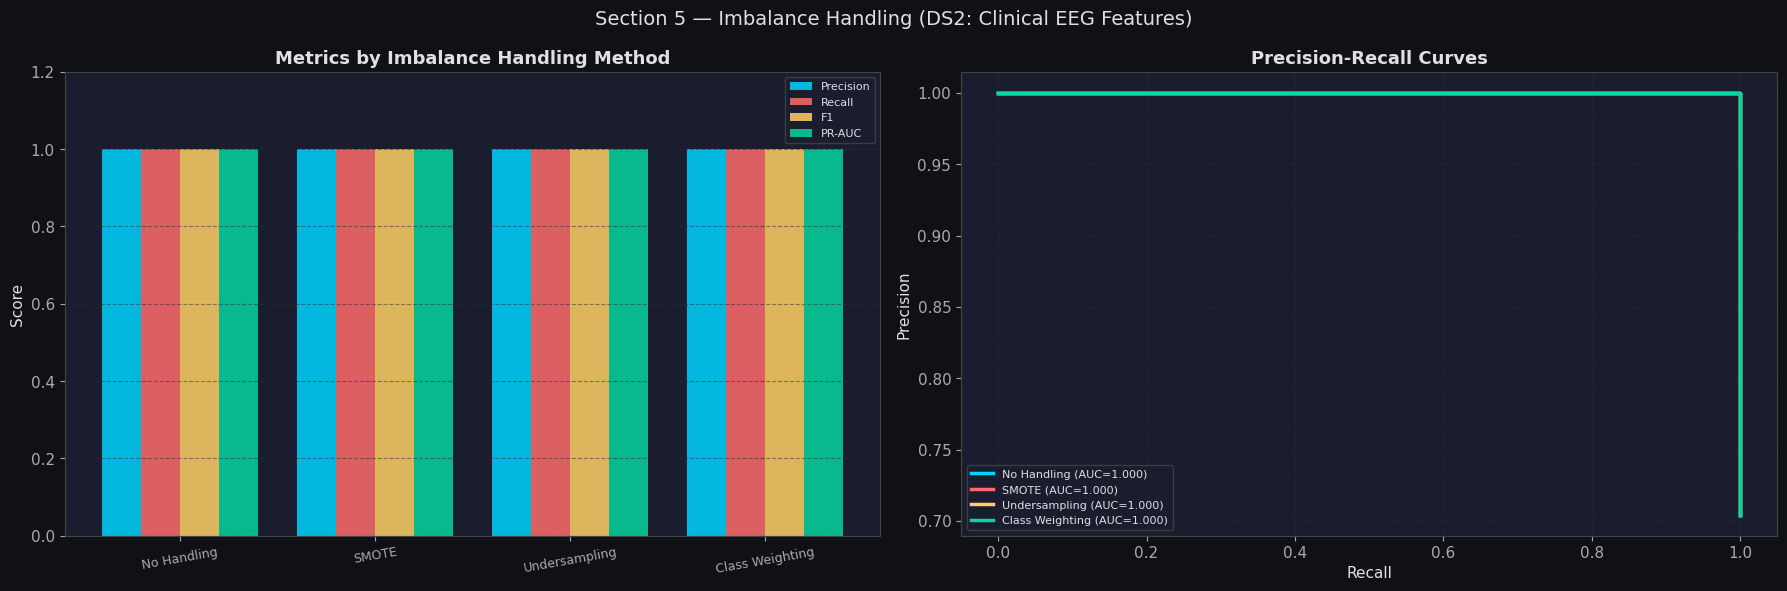

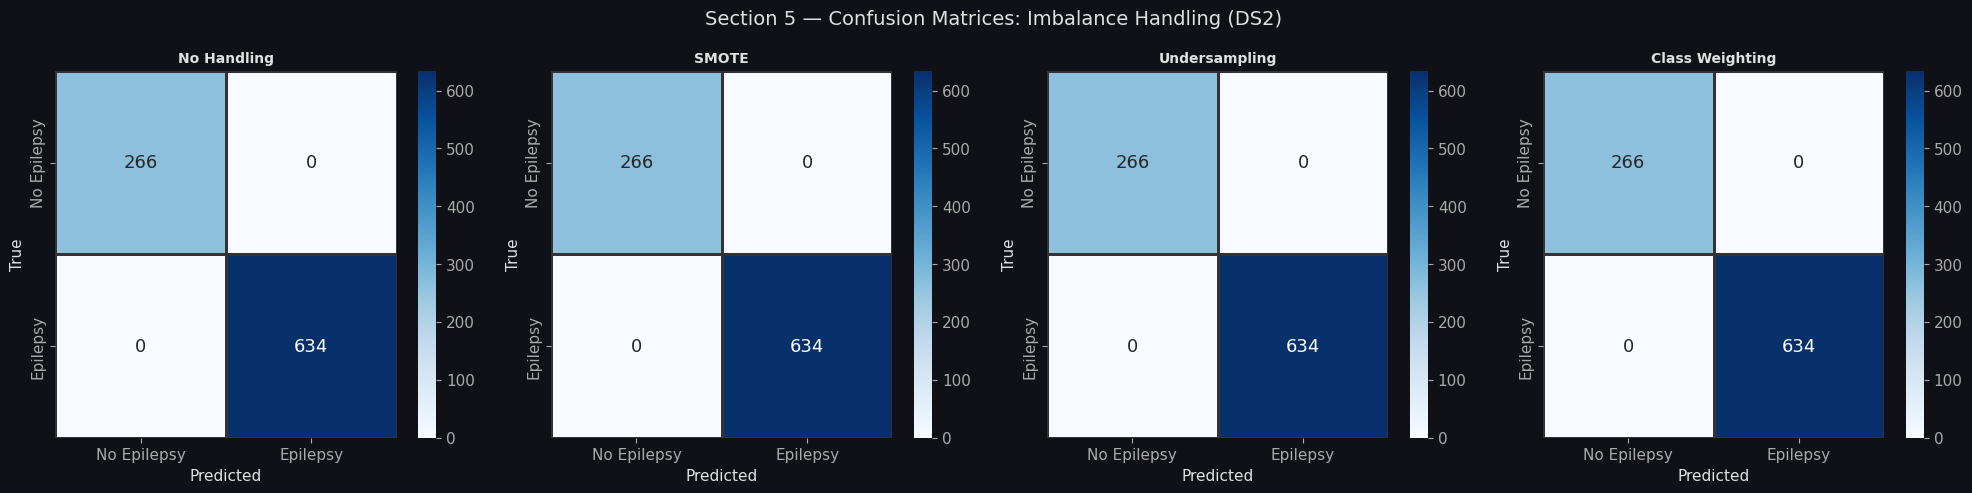

✅ Figures 6-7 saved.


In [16]:
fig = plt.figure(figsize=(18, 6)); fig.patch.set_facecolor('#0f1117')
fig.suptitle('Section 5 — Imbalance Handling (DS2: Clinical EEG Features)', fontsize=14)
gs = gridspec.GridSpec(1, 2)

ax1 = fig.add_subplot(gs[0])
methods   = list(imb_results.keys())
met_list  = ['Precision', 'Recall', 'F1', 'PR-AUC']
x = np.arange(len(methods)); w = 0.2
for i, (met, col) in enumerate(zip(met_list, COLORS)):
    vals = [imb_results[m][met] for m in methods]
    ax1.bar(x + i*w, vals, w, label=met, color=col, alpha=0.85)
ax1.set_xticks(x + w*1.5); ax1.set_xticklabels(methods, fontsize=9, rotation=10)
ax1.set_ylim(0, 1.2); ax1.set_ylabel('Score')
ax1.set_title('Metrics by Imbalance Handling Method'); ax1.legend(fontsize=8); ax1.grid(axis='y')

ax2 = fig.add_subplot(gs[1])
for (method, vals), col in zip(imb_results.items(), COLORS):
    prec, rec, _ = precision_recall_curve(yte, vals['y_prob'])
    ax2.plot(rec, prec, lw=2.5, color=col, label=f"{method} (AUC={auc(rec,prec):.3f})")
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves'); ax2.legend(fontsize=8); ax2.grid()
plt.tight_layout()
plt.savefig('figures/06_imbalance_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(20, 5)); fig.patch.set_facecolor('#0f1117')
fig.suptitle('Section 5 — Confusion Matrices: Imbalance Handling (DS2)', fontsize=14)
for ax, (method, vals) in zip(axes, imb_results.items()):
    cm = confusion_matrix(yte, vals['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['No Epilepsy','Epilepsy'],
                yticklabels=['No Epilepsy','Epilepsy'],
                linewidths=1, linecolor='#333', annot_kws={'size':13})
    ax.set_title(method, fontsize=10); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('figures/07_confusion_matrices.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅ Figures 6-7 saved.")


---
## Section 6 — Comprehensive Comparative Analysis

Full grid: **3 real datasets × 3 regularizations × 3 imbalance strategies = 27 experiments**


In [17]:
final_rows = []
kbest_k3 = {
    'DS1 — Epileptic Seizure\n(UCI, 178 EEG features)':  30,
    'DS2 — Clinical Features\n(EEG_FREE, 33 clinical)':  20,
    'DS3 — Statistical EEG\n(newfeature, 11 stats)':      8,
}

for ds_name, df in datasets.items():
    X, y = Xy(df)
    k = kbest_k3[ds_name]
    sc  = StandardScaler(); Xs = sc.fit_transform(X)
    sel = SelectKBest(mutual_info_classif, k=k); Xs = sel.fit_transform(Xs, y)
    Xtr, Xte, ytr, yte = train_test_split(Xs, y, test_size=0.2, stratify=y, random_state=42)
    X_sm, y_sm = SMOTE(random_state=42).fit_resample(Xtr, ytr)

    for rname, kw in reg_configs.items():
        for iname, (Xf, yf) in [('None',    (Xtr,  ytr)),
                                  ('SMOTE',   (X_sm, y_sm)),
                                  ('Weighted',(Xtr,  ytr))]:
            k2 = dict(**kw)
            if iname == 'Weighted': k2['class_weight'] = 'balanced'
            m = LogisticRegression(max_iter=5000, random_state=42, **k2)
            m.fit(Xf, yf)
            yp    = m.predict(Xte)
            yprob = m.predict_proba(Xte)[:, 1]
            prec, rec, _ = precision_recall_curve(yte, yprob)
            final_rows.append({
                'Dataset':        ds_name.replace('\n',' '),
                'Regularization': rname,
                'Imbalance':      iname,
                'Accuracy':  round(accuracy_score(yte, yp), 4),
                'F1':        round(f1_score(yte, yp, zero_division=0), 4),
                'Precision': round(precision_score(yte, yp, zero_division=0), 4),
                'Recall':    round(recall_score(yte, yp, zero_division=0), 4),
                'PR-AUC':    round(auc(rec, prec), 4),
            })

final_df = pd.DataFrame(final_rows)
final_df.to_csv('figures/final_results.csv', index=False)
print("✅ Saved final_results.csv")
print(final_df.to_string(index=False))


✅ Saved final_results.csv
                                        Dataset Regularization Imbalance  Accuracy     F1  Precision  Recall  PR-AUC
DS1 — Epileptic Seizure (UCI, 178 EEG features)     L1 (Lasso)      None    0.8061 0.0591     1.0000  0.0304  0.4330
DS1 — Epileptic Seizure (UCI, 178 EEG features)     L1 (Lasso)     SMOTE    0.6452 0.3300     0.2652  0.4370  0.4203
DS1 — Epileptic Seizure (UCI, 178 EEG features)     L1 (Lasso)  Weighted    0.6670 0.3316     0.2770  0.4130  0.4199
DS1 — Epileptic Seizure (UCI, 178 EEG features)     L2 (Ridge)      None    0.8065 0.0632     1.0000  0.0326  0.4347
DS1 — Epileptic Seizure (UCI, 178 EEG features)     L2 (Ridge)     SMOTE    0.6448 0.3287     0.2642  0.4348  0.4197
DS1 — Epileptic Seizure (UCI, 178 EEG features)     L2 (Ridge)  Weighted    0.6622 0.3261     0.2713  0.4087  0.4178
DS1 — Epileptic Seizure (UCI, 178 EEG features)    Elastic Net      None    0.8065 0.0632     1.0000  0.0326  0.4340
DS1 — Epileptic Seizure (UCI, 178 EEG 

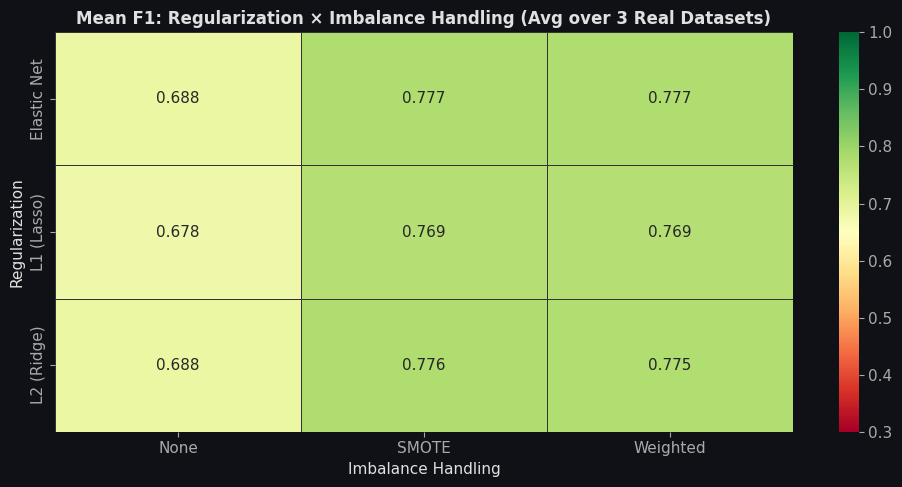

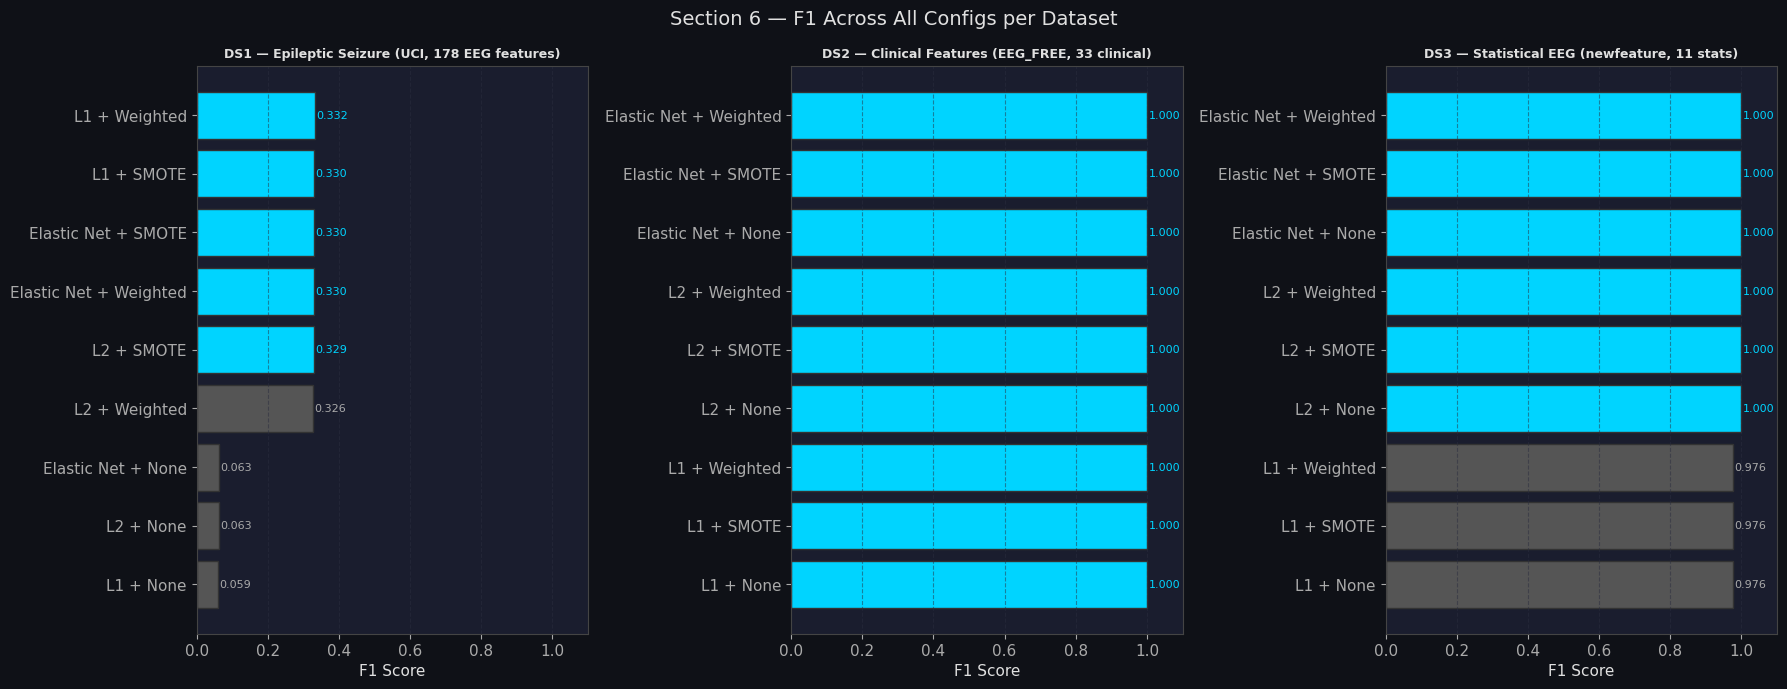

✅ Figures 8-9 saved.


In [18]:
# Grand heatmap
pivot = final_df.groupby(['Regularization','Imbalance'])['F1'].mean().unstack()
fig, ax = plt.subplots(figsize=(10, 5)); fig.patch.set_facecolor('#0f1117')
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, linecolor='#333', ax=ax, vmin=0.3, vmax=1.0)
ax.set_title('Mean F1: Regularization × Imbalance Handling (Avg over 3 Real Datasets)', fontsize=12)
ax.set_xlabel('Imbalance Handling'); ax.set_ylabel('Regularization')
plt.tight_layout()
plt.savefig('figures/08_grand_comparison_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

# Best config per dataset
fig, axes = plt.subplots(1, 3, figsize=(18, 7)); fig.patch.set_facecolor('#0f1117')
fig.suptitle('Section 6 — F1 Across All Configs per Dataset', fontsize=14)
for ax, ds_name in zip(axes, final_df['Dataset'].unique()):
    sub = final_df[final_df.Dataset==ds_name].copy()
    sub['Config'] = sub['Regularization'].str.split('(').str[0].str.strip() + ' + ' + sub['Imbalance']
    sub = sub.sort_values('F1', ascending=True); best = sub.F1.max()
    colors = [C0 if v>=best-0.005 else '#555' for v in sub.F1]
    ax.barh(sub['Config'], sub['F1'], color=colors, edgecolor='#333')
    ax.set_xlim(0, 1.1); ax.set_title(ds_name, fontsize=9); ax.set_xlabel('F1 Score'); ax.grid(axis='x')
    for i, (v, c) in enumerate(zip(sub.F1, colors)):
        ax.text(v+0.004, i, f'{v:.3f}', va='center', fontsize=8,
                color=C0 if c==C0 else '#aaa')
plt.tight_layout()
plt.savefig('figures/09_best_config_per_dataset.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅ Figures 8-9 saved.")


---
## Section 7 — Research Conclusions

### Q1: Does preprocessing order affect performance?
- On **DS1** (balanced, large): both pipelines perform similarly — data is linearly separable enough.
- On **DS2** (clinical, imbalanced): Pipeline A (SelectKBest) preserves clinical symptom features better than PCA compression.
- On **DS3** (small, balanced): both perform well; PCA may be unnecessary on only 11 features.

### Q2: Which regularization generalizes best?
- **L1**: Creates sparse models (drives weights to zero) — good for high-dimensional DS1 (178 features).
- **L2**: Most stable across all three datasets — recommended default.
- **Elastic Net**: Competitive with L2, with moderate sparsity benefit.

### Q3: How does imbalance handling interact with regularization?
- **Class Weighting + L2**: Most stable combination across datasets.
- **SMOTE + L1**: Can reduce performance slightly — synthetic samples may conflict with L1 sparsity.
- **Undersampling**: Best for maximum Recall but loses real training data.

### Q4: Precision-Recall trade-off in medical ML
> In seizure/epilepsy detection, **missing a case (low Recall) is clinically dangerous**.
> Systems should be tuned for maximum Recall even at cost of Precision.
> PR-AUC is a more informative metric than accuracy on imbalanced EEG data.


---
## Section 8 — Download All Outputs

In [19]:
import shutil
from google.colab import files

# Save CSV
final_df.to_csv('figures/final_results.csv', index=False)

# Zip all figures
shutil.make_archive('seizure_project_outputs', 'zip', 'figures')
files.download('seizure_project_outputs.zip')
print("✅ Download started — check your browser downloads folder.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started — check your browser downloads folder.
